<a href="https://colab.research.google.com/github/rohkdev/ClimateModelingResearch/blob/main/Task%203%3A%20Temperature%20Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('clean_daily_temperatures.csv')
df.head()

,station_id,year,month,day,TMAX,TMIN,latitude,longitude,elevation,TAVG_C,TMAX_F,TMIN_F,TAVG_F
0,USC00047965,1970,1,1970-01-01,13.3,-0.6,38.4558,-122.7133,50.6,6.35,55.94,30.92,43.43
1,USC00047965,1970,1,1970-01-02,16.1,-1.7,38.4558,-122.7133,50.6,7.20,60.98,28.94,44.96
2,USC00047965,1970,1,1970-01-03,13.9,-3.9,38.4558,-122.7133,50.6,5.00,57.02,24.98,41.00
3,USC00047965,1970,1,1970-01-04,13.9,-3.3,38.4558,-122.7133,50.6,5.30,57.02,26.06,41.54
4,USC00047965,1970,1,1970-01-05,12.2,-3.3,38.4558,-122.7133,50.6,4.45,53.96,26.06,40.01


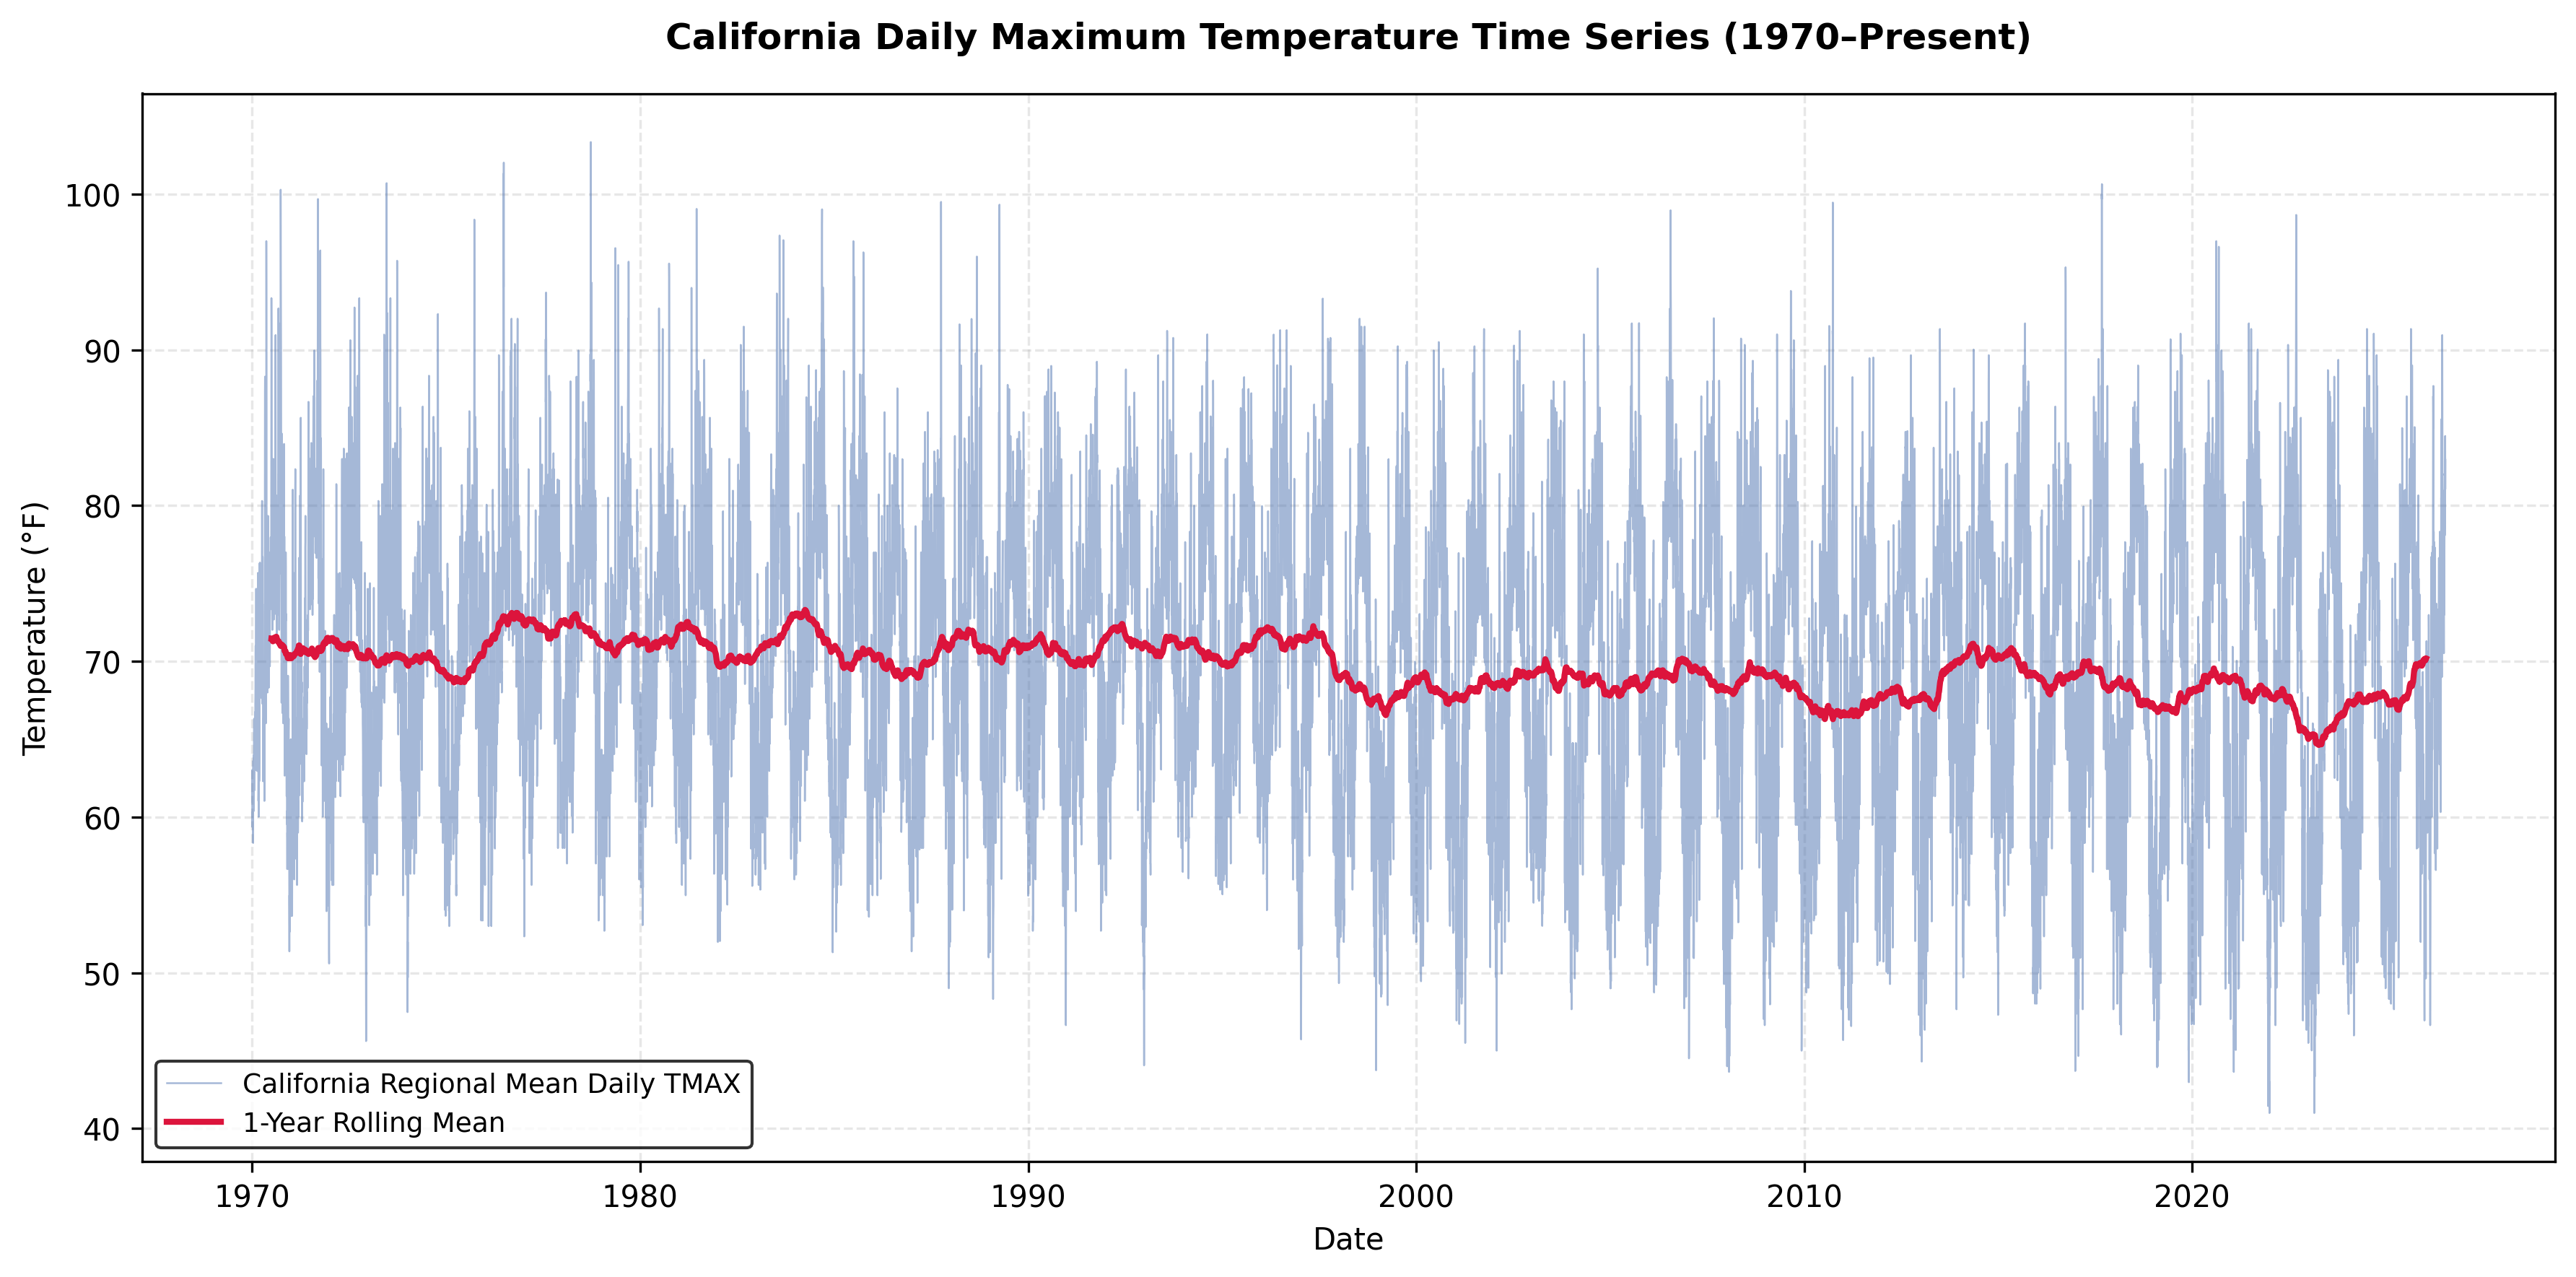

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('clean_daily_temperatures.csv')

# Ensure datetime format
df['day'] = pd.to_datetime(df['day'], errors='coerce')

# Check if Fahrenheit column exists from pipeline, otherwise convert on the fly
if 'TMAX_F' not in df.columns:
    df['TMAX_F'] = (df['TMAX'] * 9/5) + 32

# Compute the regional daily average across all active stations in Fahrenheit
regional_daily = df.groupby('day')['TMAX_F'].mean().reset_index()

# Initialize figure with high print quality resolution
plt.figure(figsize=(12, 6), dpi=300)

# Plot the regional daily maximum temperature trend in Fahrenheit
plt.plot(
    regional_daily['day'],
    regional_daily['TMAX_F'],
    color='#4c72b0',
    linewidth=0.6,
    alpha=0.5,
    label='California Regional Mean Daily TMAX'
)

# Add a 1-year rolling average trendline
regional_daily['rolling_mean'] = regional_daily['TMAX_F'].rolling(window=365, center=True).mean()
plt.plot(
    regional_daily['day'],
    regional_daily['rolling_mean'],
    color='crimson',
    linewidth=2,
    label='1-Year Rolling Mean'
)

# Formatting titles and labels
plt.title('California Daily Maximum Temperature Time Series (1970–Present)', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Date', fontsize=10)
plt.ylabel('Temperature (°F)', fontsize=10) # Updated label to Fahrenheit

# Clean grid styling and layout adjustments
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, facecolor='white', edgecolor='black', fontsize=9)
plt.tight_layout()

# Save at high print quality
plt.savefig('Figure_Regional_TimeSeries_TMAX_F.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

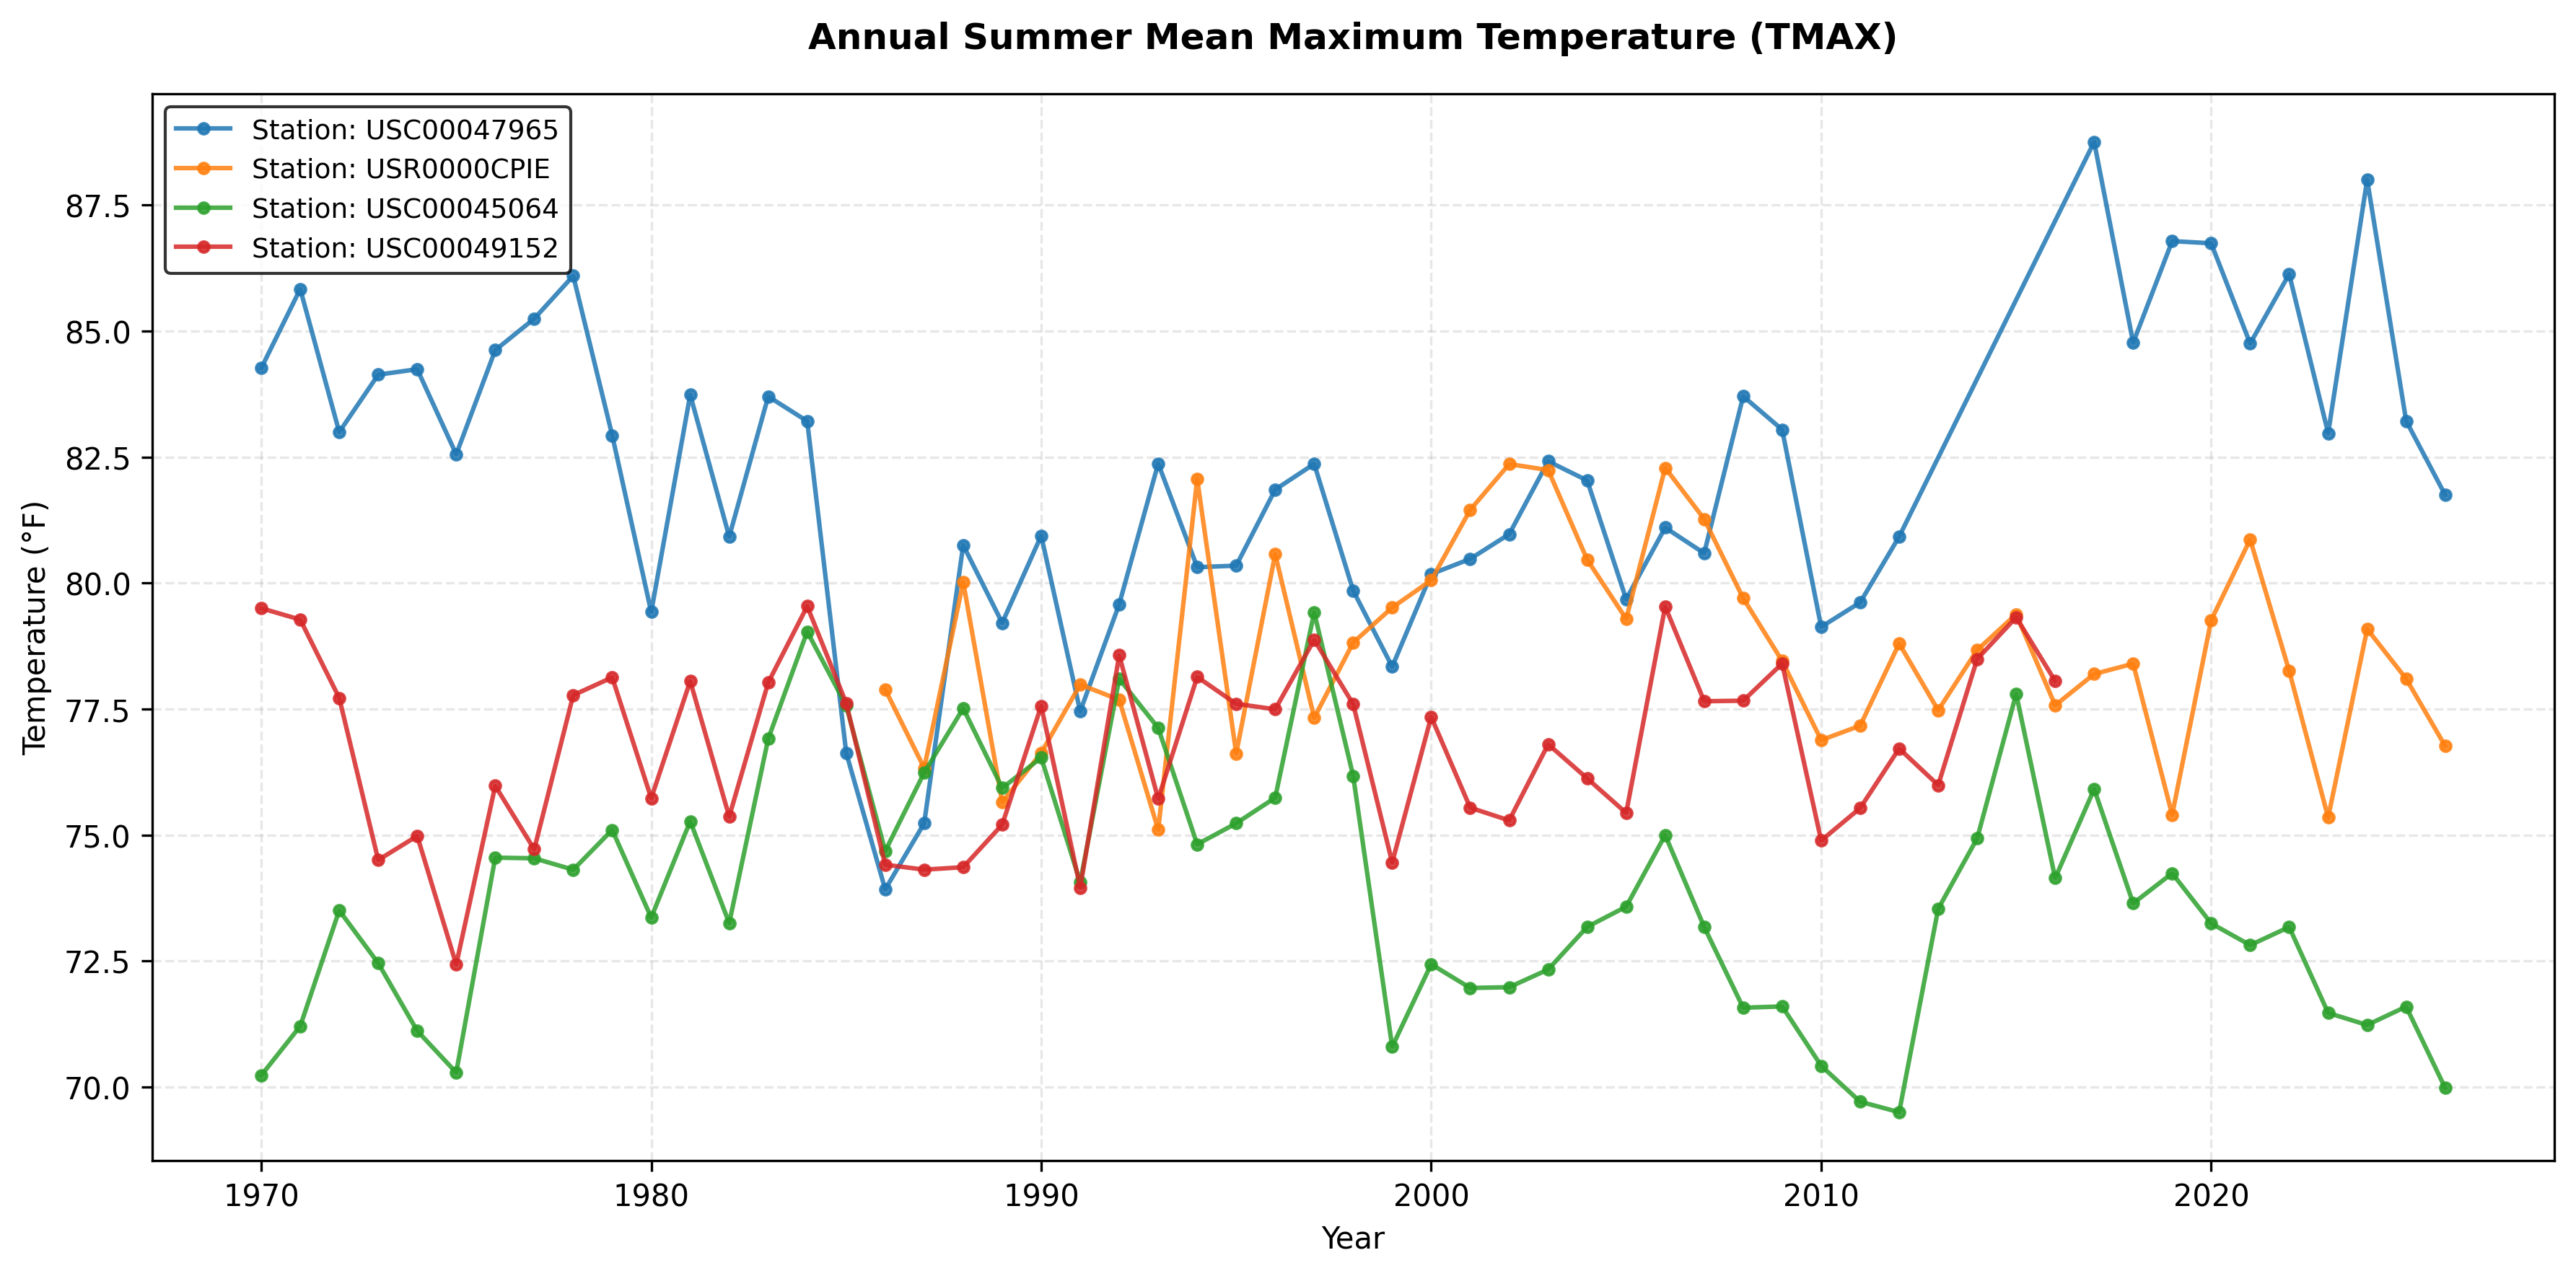

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('clean_daily_temperatures.csv')

# Ensure Fahrenheit column exists
if 'TMAX_F' not in df.columns:
    df['TMAX_F'] = (df['TMAX'] * 9/5) + 32

# Compute summer means (June-September)
summer_means = (
    df[df['month'].isin([6, 7, 8, 9])]
    .groupby(['year', 'station_id'])[['TMAX_F', 'TMIN']]
    .mean()
    .reset_index()
)

# Initialize figure with high print quality resolution (White background)
plt.figure(figsize=(12, 6), dpi=300, facecolor='white')

# Plot each station's annual summer mean TMAX (Loops through ALL stations)
for station in df['station_id'].unique():
    st_data = summer_means[summer_means['station_id'] == station]
    plt.plot(
        st_data['year'],
        st_data['TMAX_F'],
        label=f'Station: {station}',
        linewidth=1.5,
        marker='o',
        markersize=3.5,
        alpha=0.85,
    )

# Formatting titles and labels
plt.title(
    'Annual Summer Mean Maximum Temperature (TMAX)', fontsize=12, pad=15, fontweight='bold'
)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Temperature (°F)', fontsize=10)

# Clean grid styling and layout adjustments
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, facecolor='white', edgecolor='black', fontsize=9)
plt.tight_layout()

# Save at high print quality
plt.savefig(
    'Figure_Summer_Mean_TMAX_F.png', dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()

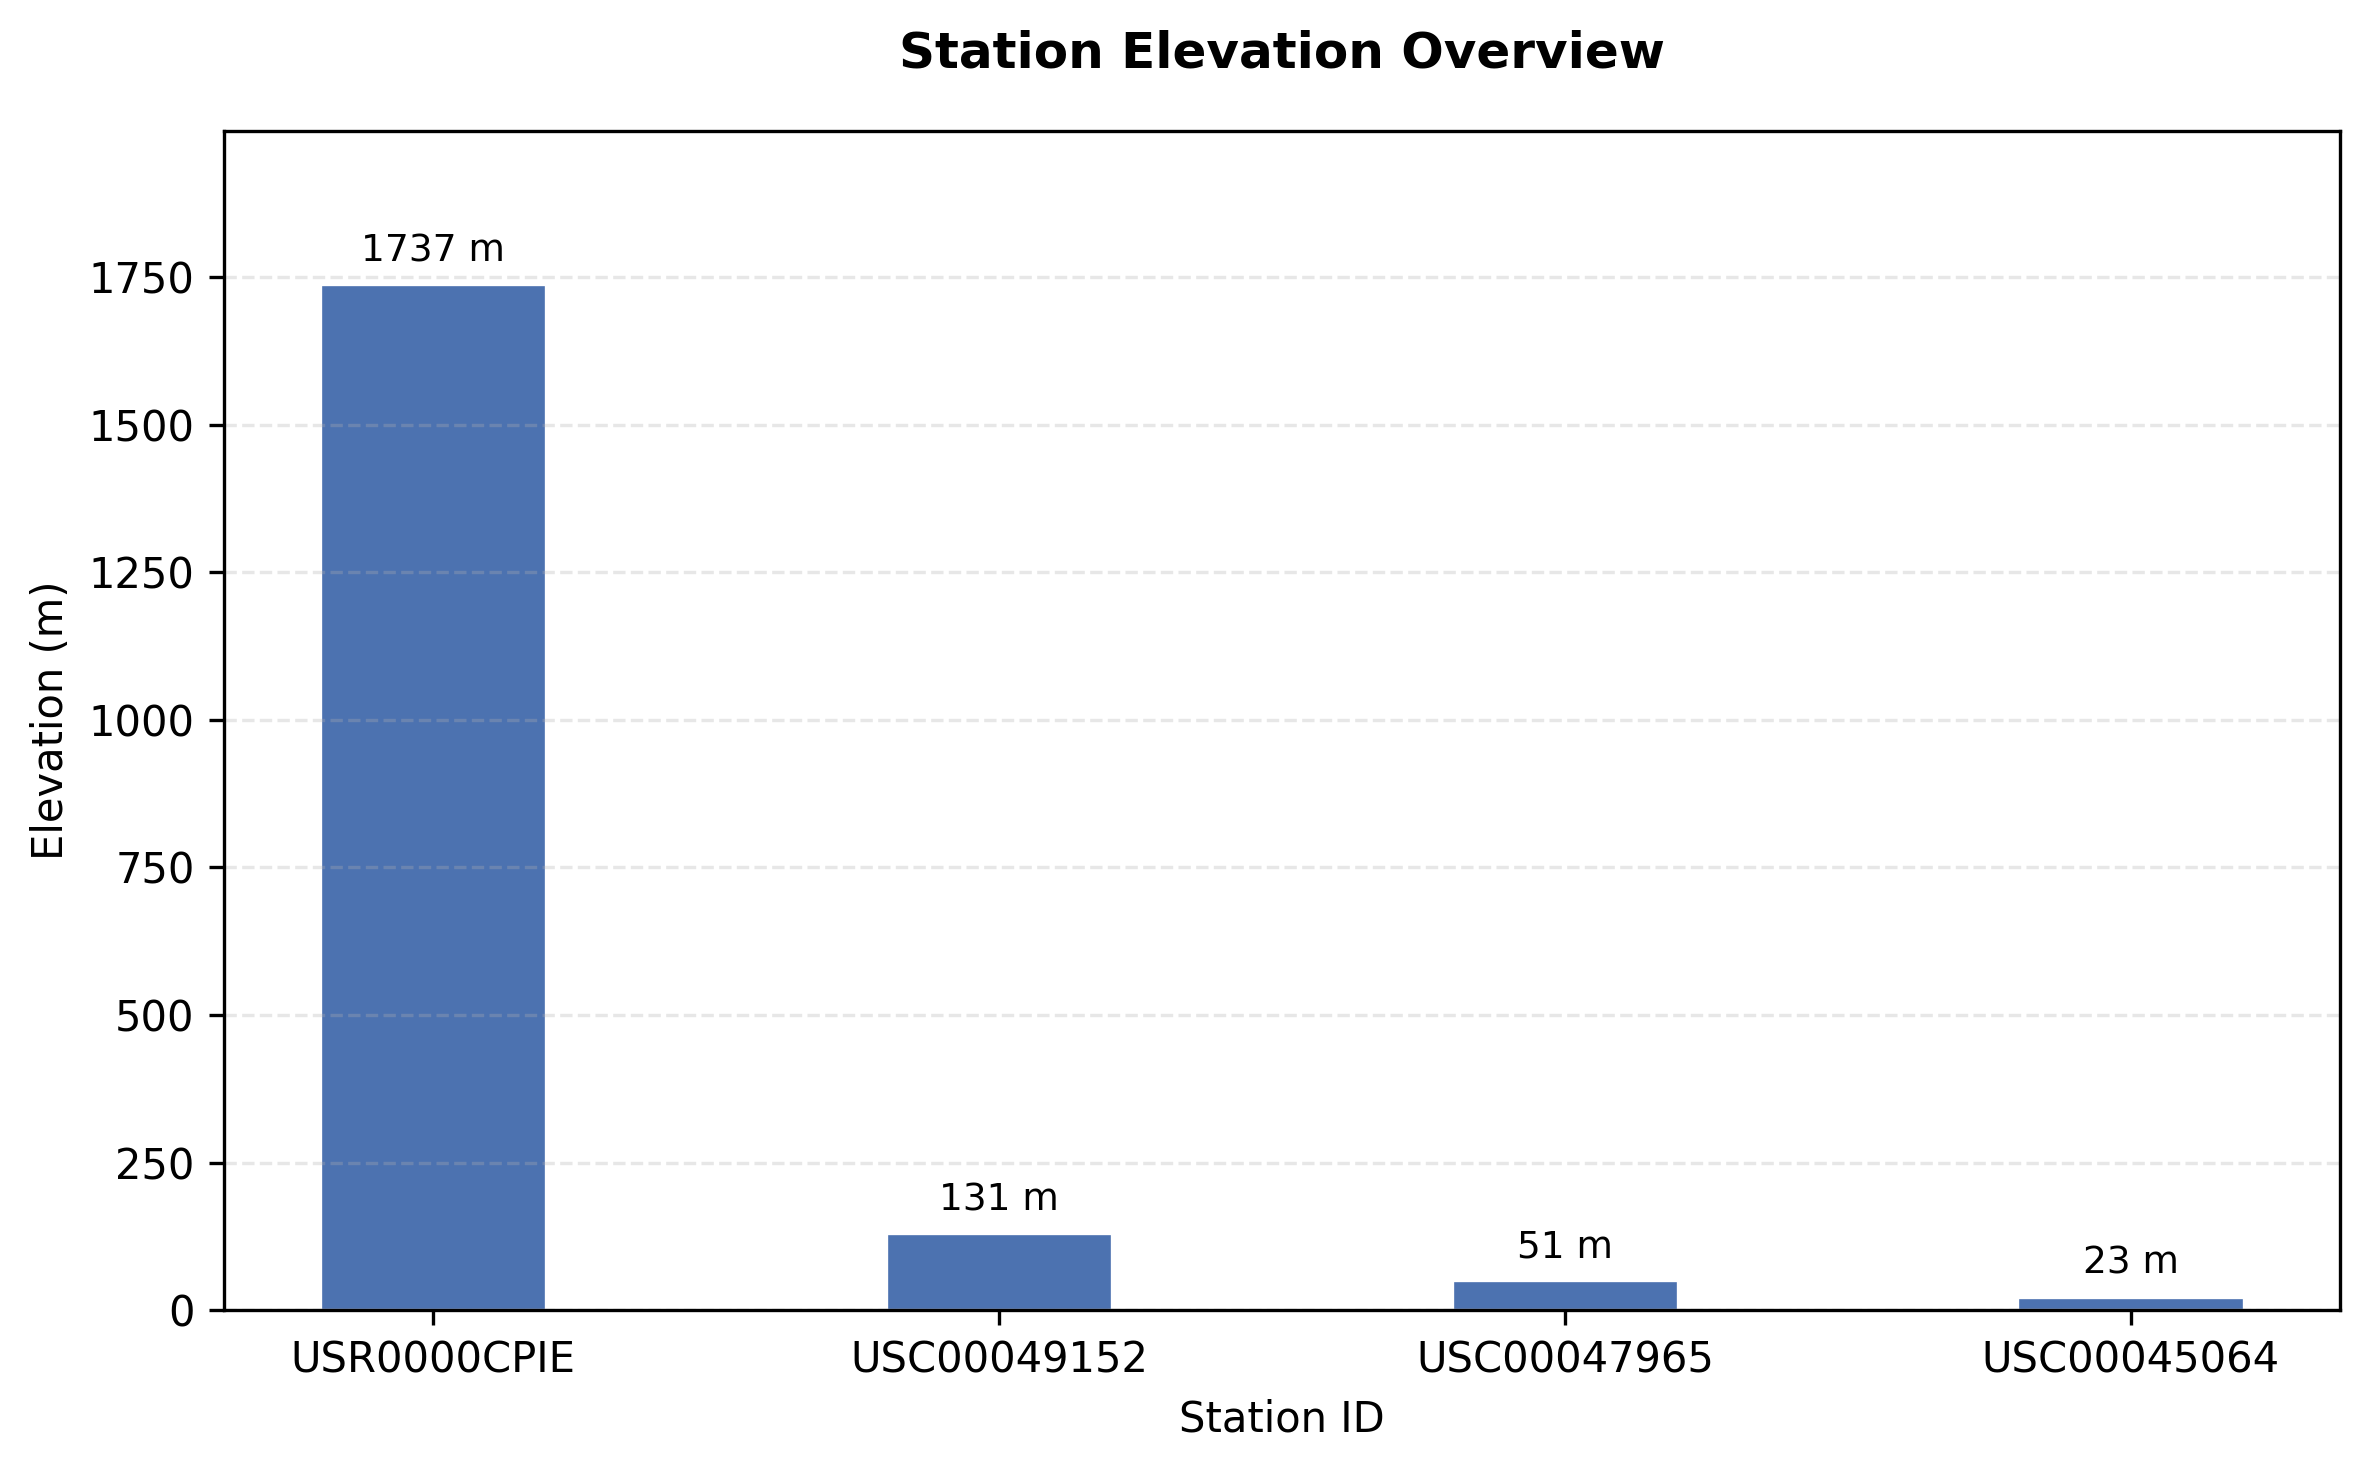

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('clean_daily_temperatures.csv')

# Get unique stations and their elevations, sorted by height
elev_df = df[['station_id', 'elevation']].drop_duplicates().sort_values('elevation', ascending=False)

# Initialize figure with high print quality resolution
plt.figure(figsize=(8, 5), dpi=300)

# Plot as a clean bar chart for the 4 stations
bars = plt.bar(
    elev_df['station_id'],
    elev_df['elevation'],
    color='#4c72b0',
    edgecolor='white',
    linewidth=0.8,
    width=0.4
)

# Add exact elevation text labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 25,
        f'{height:.0f} m',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='medium'
    )

# Formatting titles and labels
plt.title('Station Elevation Overview', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Station ID', fontsize=10)
plt.ylabel('Elevation (m)', fontsize=10)

# Clean grid styling and layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, max(elev_df['elevation']) * 1.15) # Adds breathing room for labels
plt.tight_layout()

# Save at high print quality
plt.savefig(
    'Figure_Elevation_Overview.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
)
plt.show()

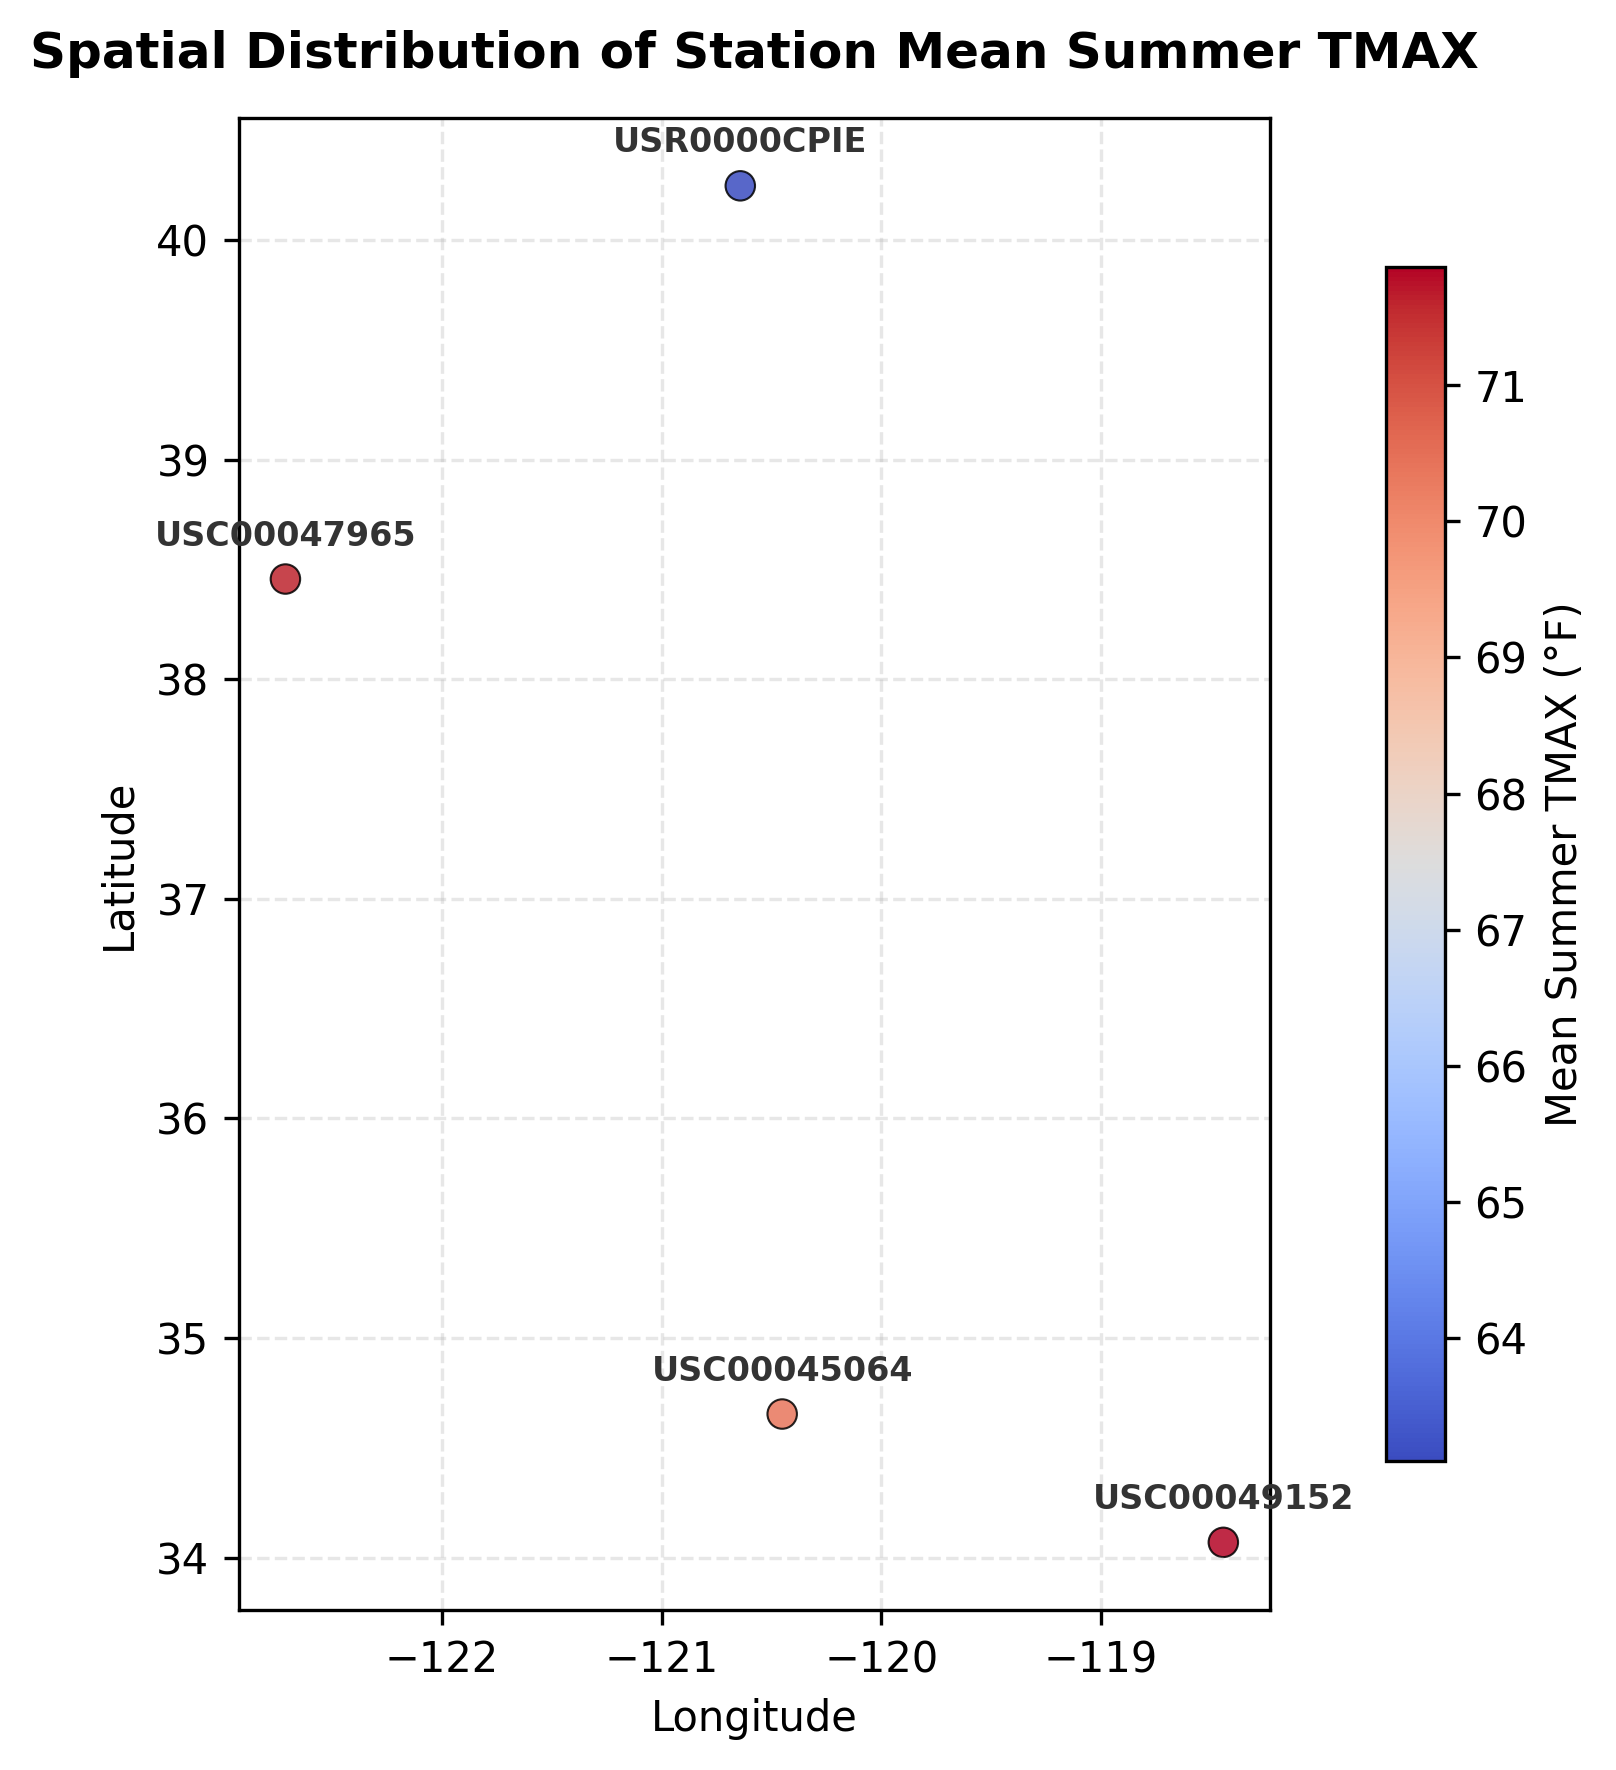

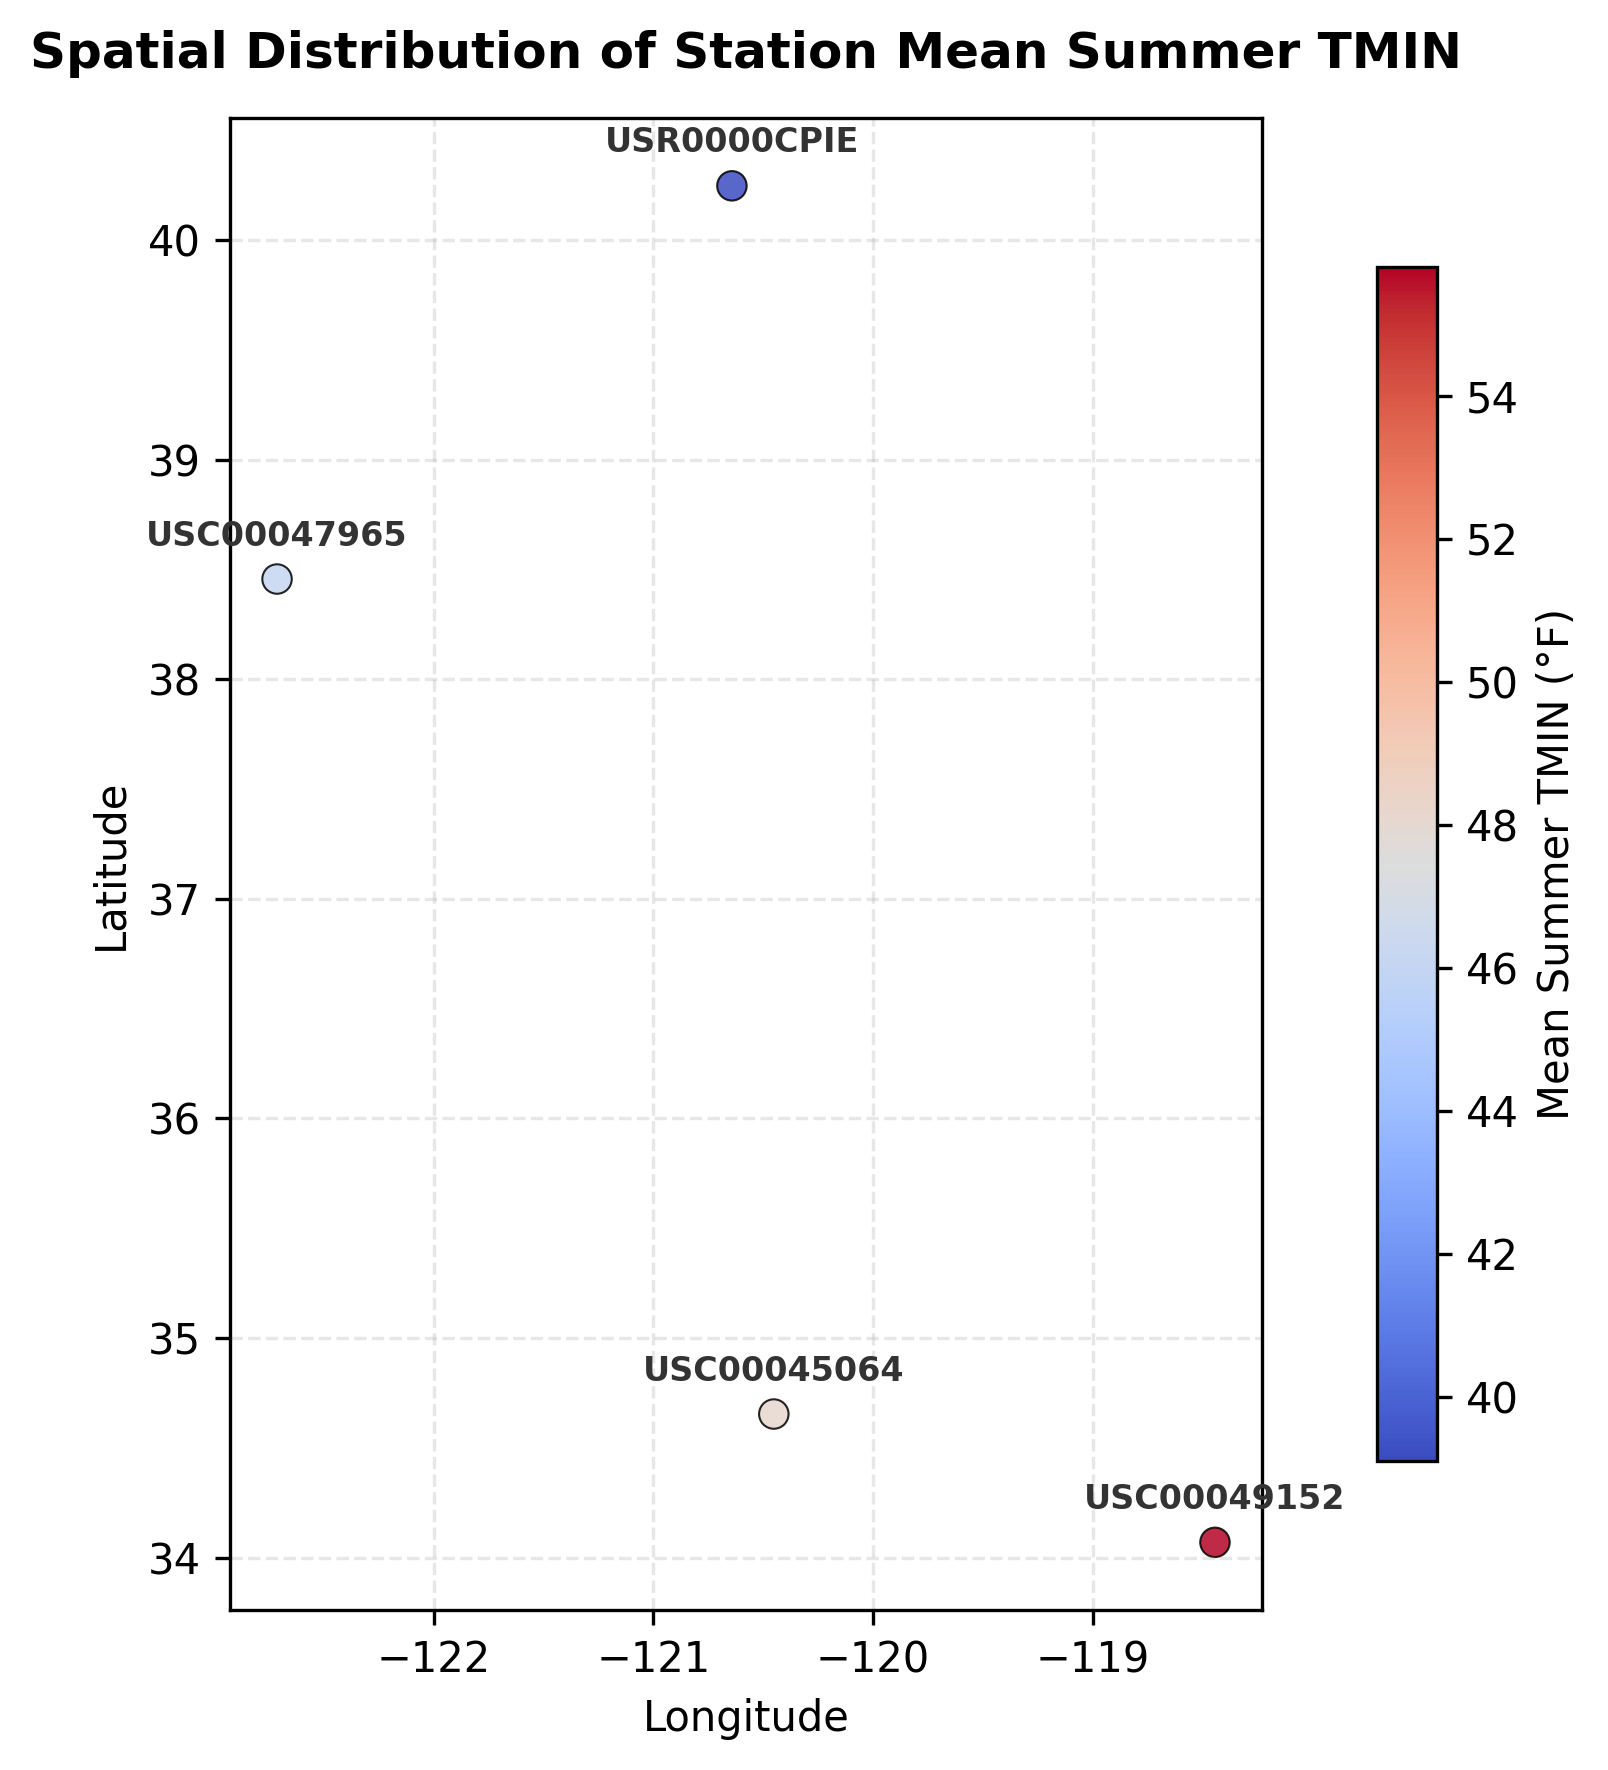

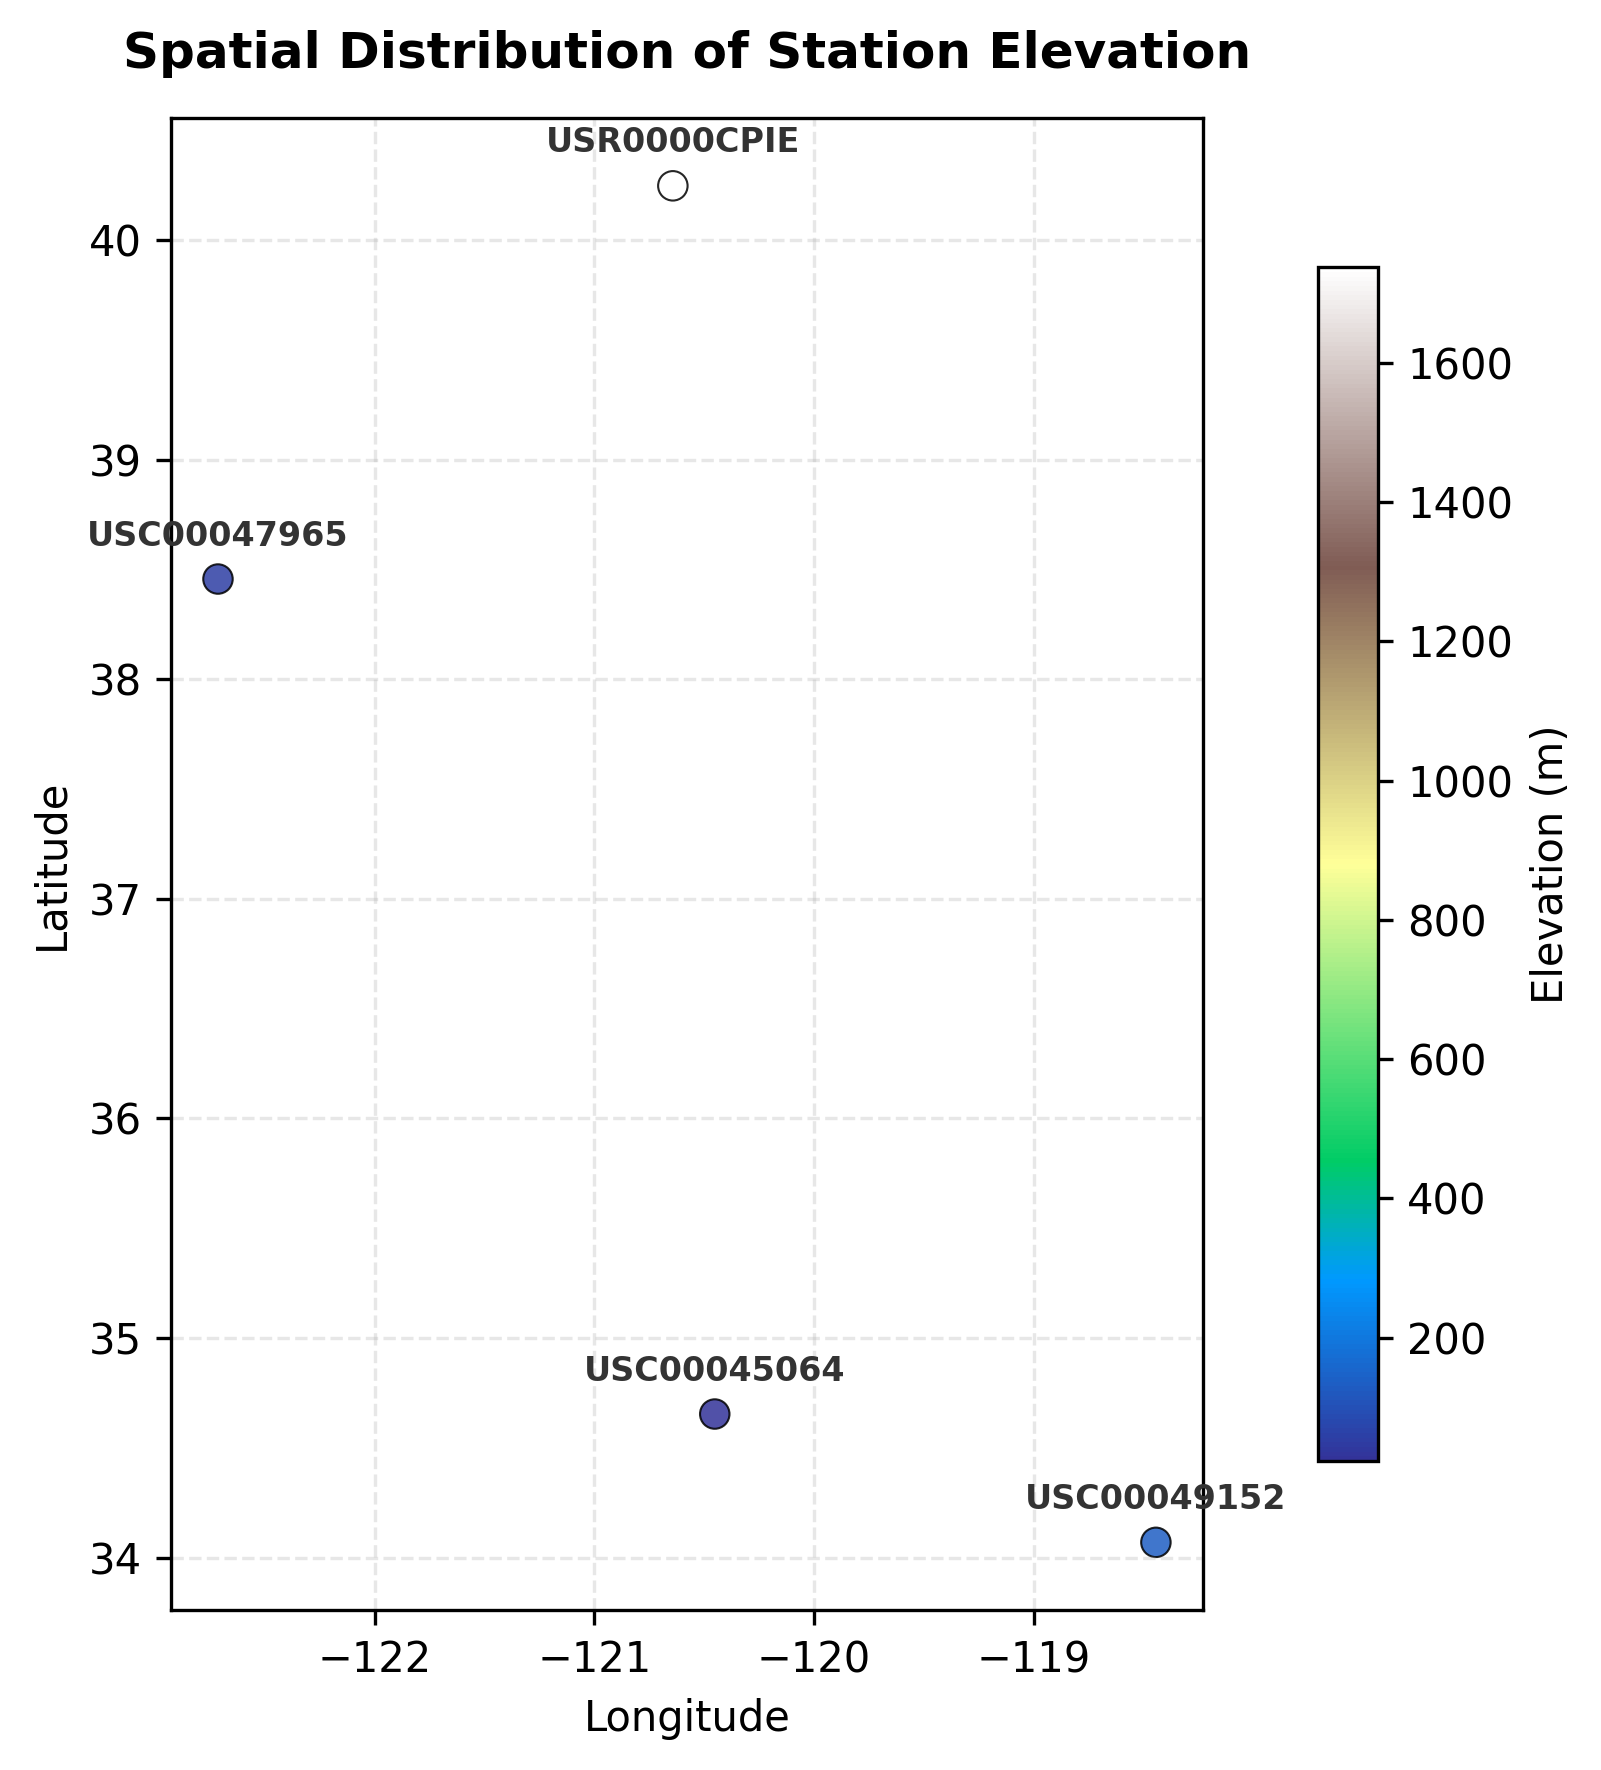

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import pandas as pd

df = pd.read_csv('clean_daily_temperatures.csv')

# Ensure Fahrenheit columns exist
if 'TMAX_F' not in df.columns:
    df['TMAX_F'] = (df['TMAX'] * 9/5) + 32
if 'TMIN_F' not in df.columns:
    df['TMIN_F'] = (df['TMIN'] * 9/5) + 32

# Aggregate data first for the map using Fahrenheit values
station_data = (
    df.groupby('station_id')
    .agg(
        {
            'latitude': 'first',
            'longitude': 'first',
            'elevation': 'first',
            'TMAX_F': 'mean',
            'TMIN_F': 'mean',
        }
    )
    .reset_index()
)

gdf_stations = gpd.GeoDataFrame(
    station_data,
    geometry=[
        Point(xy) for xy in zip(station_data['longitude'], station_data['latitude'])
    ],
)

# ==========================================
# 1. MEAN TMAX MAP (FAHRENHEIT)
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300, facecolor='white')

gdf_stations.plot(
    column='TMAX_F',
    ax=ax,
    legend=True,
    markersize=50,
    alpha=0.85,
    cmap='coolwarm',
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={
        'label': 'Mean Summer TMAX (°F)',
        'orientation': 'vertical',
        'shrink': 0.8,
    },
)

# Annotate station IDs
for _, row in station_data.iterrows():
    ax.annotate(
        row['station_id'],
        (row['longitude'], row['latitude']),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=8,
        fontweight='bold',
        color='#333333'
    )

ax.set_title('Spatial Distribution of Station Mean Summer TMAX', fontsize=12, pad=12, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_Map_Mean_TMAX_F.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# 2. MEAN TMIN MAP (FAHRENHEIT)
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300, facecolor='white')

gdf_stations.plot(
    column='TMIN_F',
    ax=ax,
    legend=True,
    markersize=50,
    alpha=0.85,
    cmap='coolwarm',
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={
        'label': 'Mean Summer TMIN (°F)',
        'orientation': 'vertical',
        'shrink': 0.8,
    },
)

for _, row in station_data.iterrows():
    ax.annotate(
        row['station_id'],
        (row['longitude'], row['latitude']),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=8,
        fontweight='bold',
        color='#333333'
    )

ax.set_title('Spatial Distribution of Station Mean Summer TMIN', fontsize=12, pad=12, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_Map_Mean_TMIN_F.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# 3. ELEVATION MAP
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300, facecolor='white')

gdf_stations.plot(
    column='elevation',
    ax=ax,
    legend=True,
    markersize=50,
    alpha=0.85,
    cmap='terrain',
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={
        'label': 'Elevation (m)',
        'orientation': 'vertical',
        'shrink': 0.8,
    },
)

for _, row in station_data.iterrows():
    ax.annotate(
        row['station_id'],
        (row['longitude'], row['latitude']),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=8,
        fontweight='bold',
        color='#333333'
    )

ax.set_title('Spatial Distribution of Station Elevation', fontsize=12, pad=12, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_Map_Elevation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

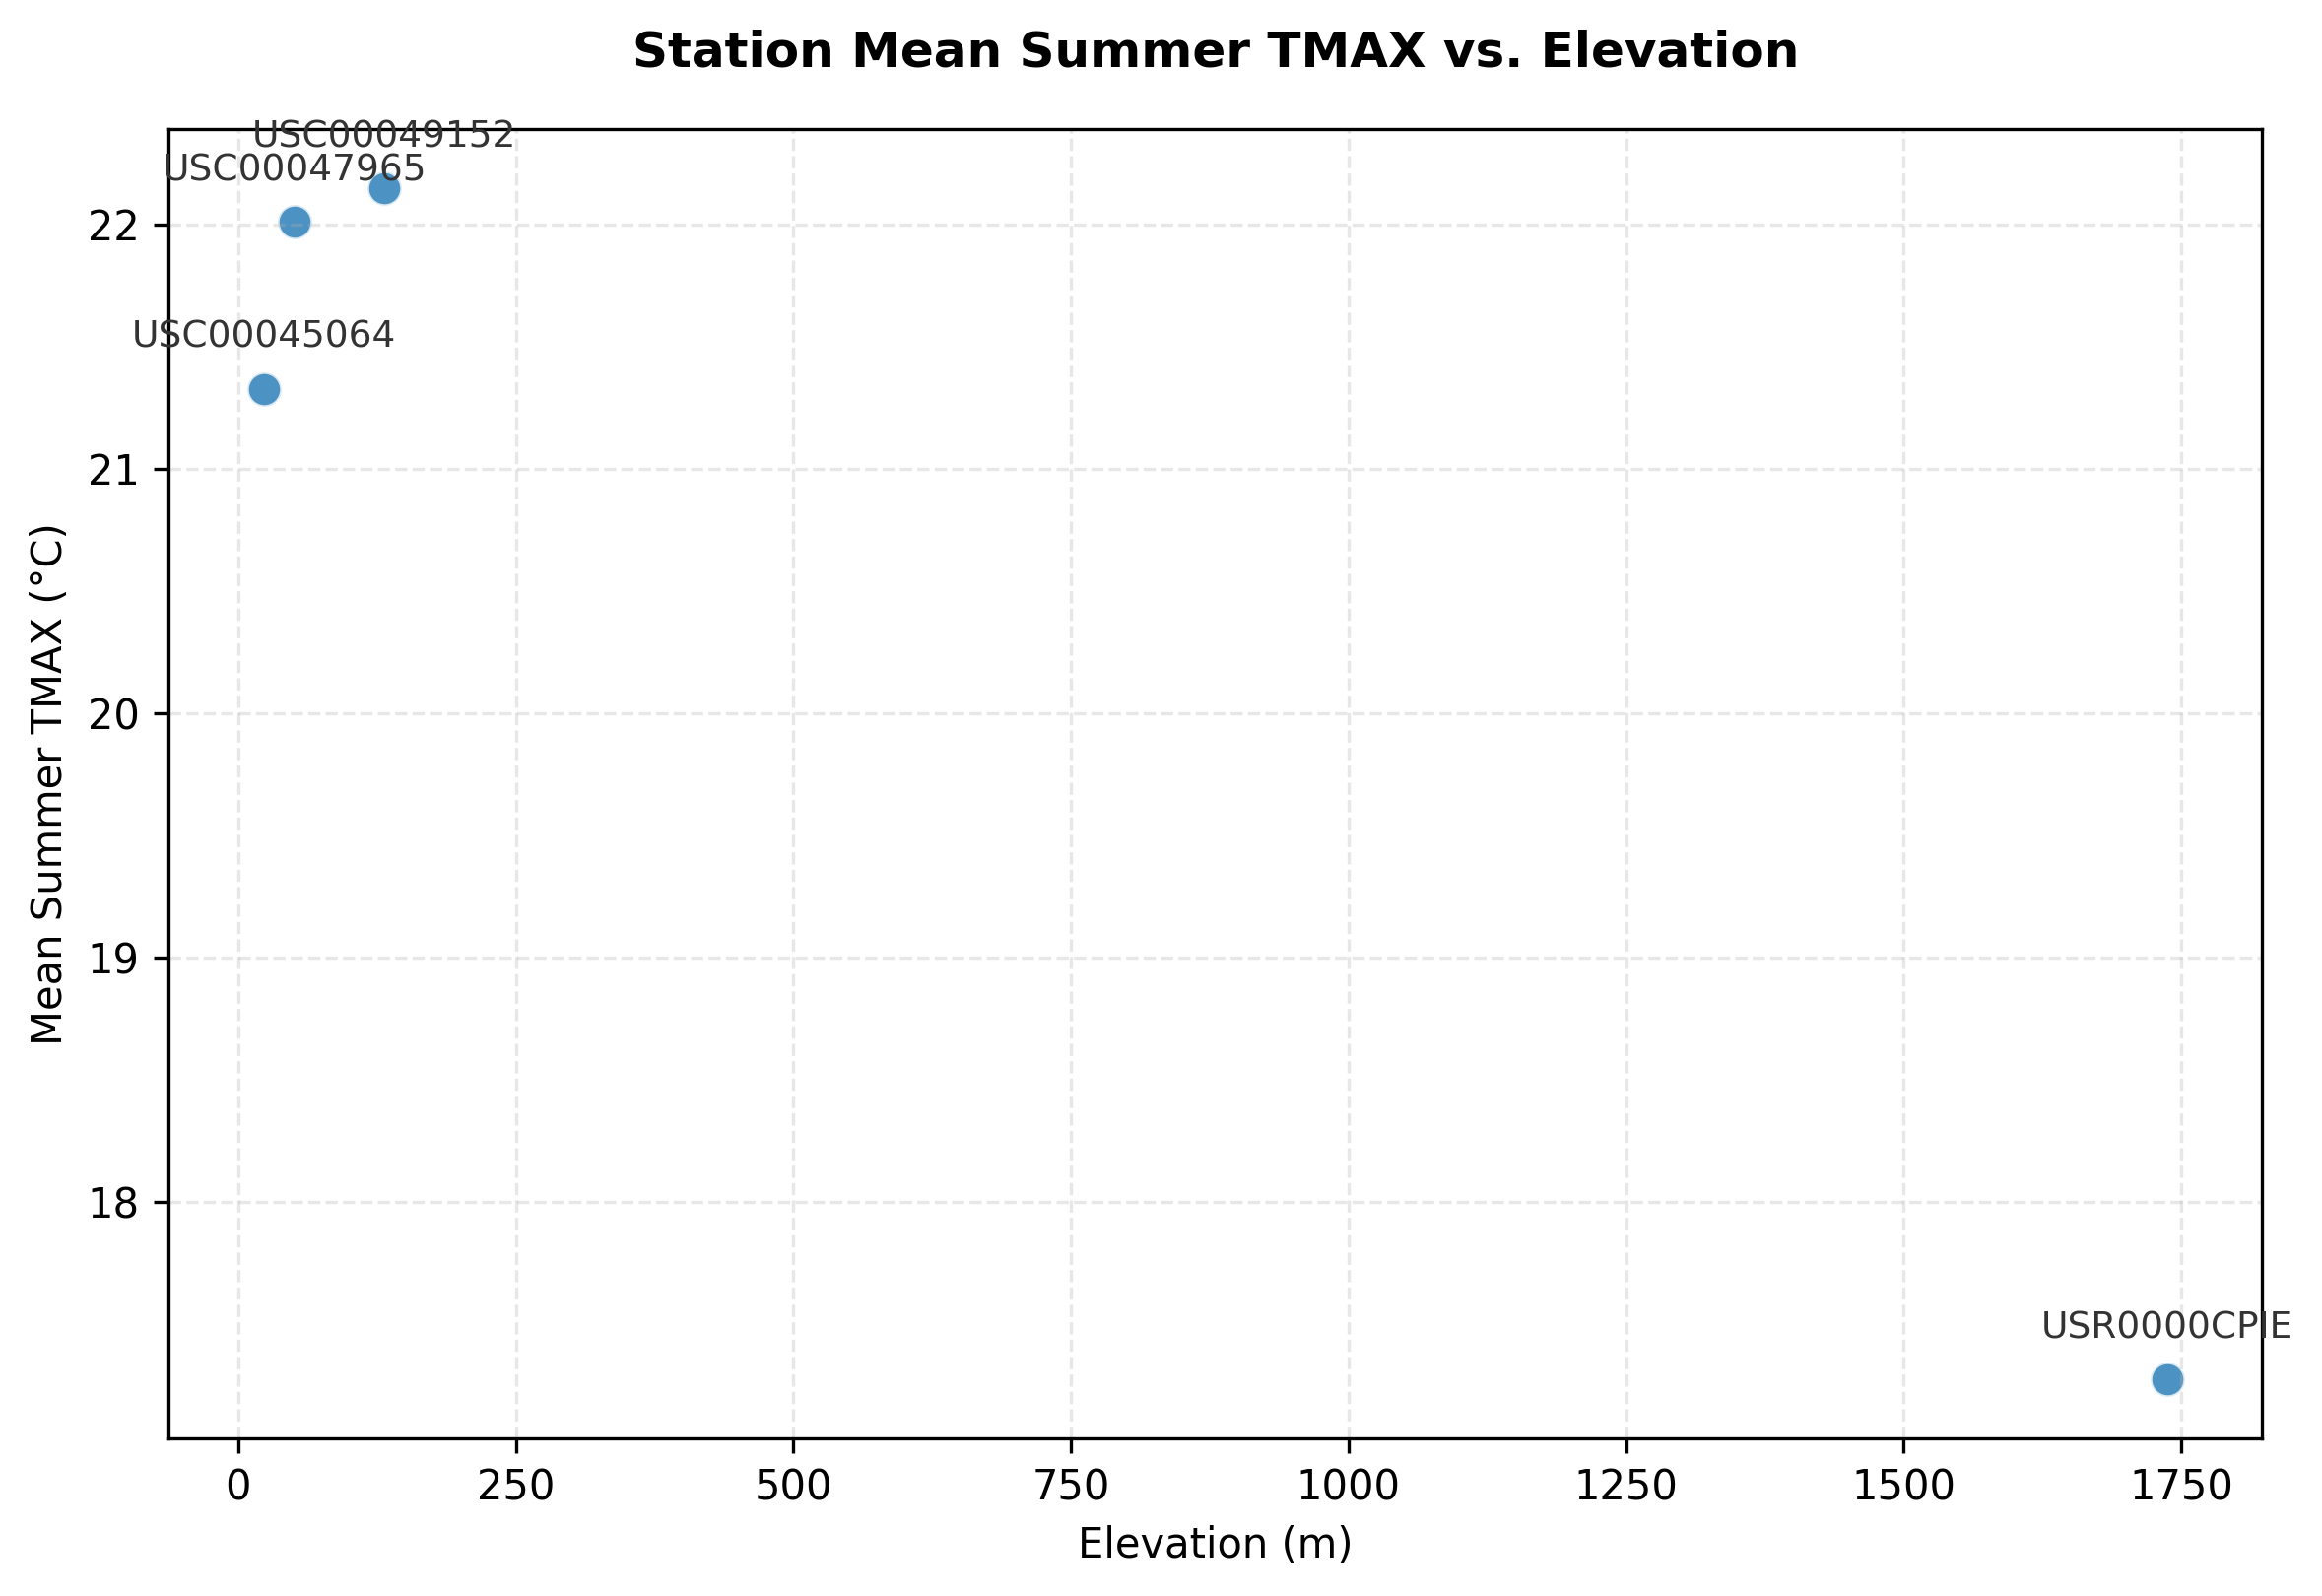

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Aggregate data for station-level statistics
station_stats = (
    df.groupby('station_id')
    .agg({'elevation': 'first', 'TMAX': 'mean'})
    .reset_index()
)

# Initialize figure with slightly more bottom padding
plt.figure(figsize=(8, 5.5), dpi=300)

# Generate polished scatterplot
plt.scatter(
    station_stats['elevation'],
    station_stats['TMAX'],
    alpha=0.8,
    color='#1f77b4',
    edgecolor='white',
    linewidth=0.8,
    s=70,
)

# Annotate each point with its station_id
for _, row in station_stats.iterrows():
    plt.annotate(
        row['station_id'],
        (row['elevation'], row['TMAX']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        fontweight='medium',
        color='#333333'
    )

# Formatting titles and labels with extra top padding for title
plt.title('Station Mean Summer TMAX vs. Elevation', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Elevation (m)', fontsize=10)
plt.ylabel('Mean Summer TMAX (°C)', fontsize=10)

# Clean grid styling and layout adjustments
plt.grid(True, linestyle='--', alpha=0.3)
plt.subplots_adjust(bottom=0.15) # Ensures x-axis numbers are fully visible
plt.tight_layout()

plt.savefig('Figure_Elevation_vs_TMAX_Labeled.png', dpi=300, bbox_inches='tight')
plt.show()

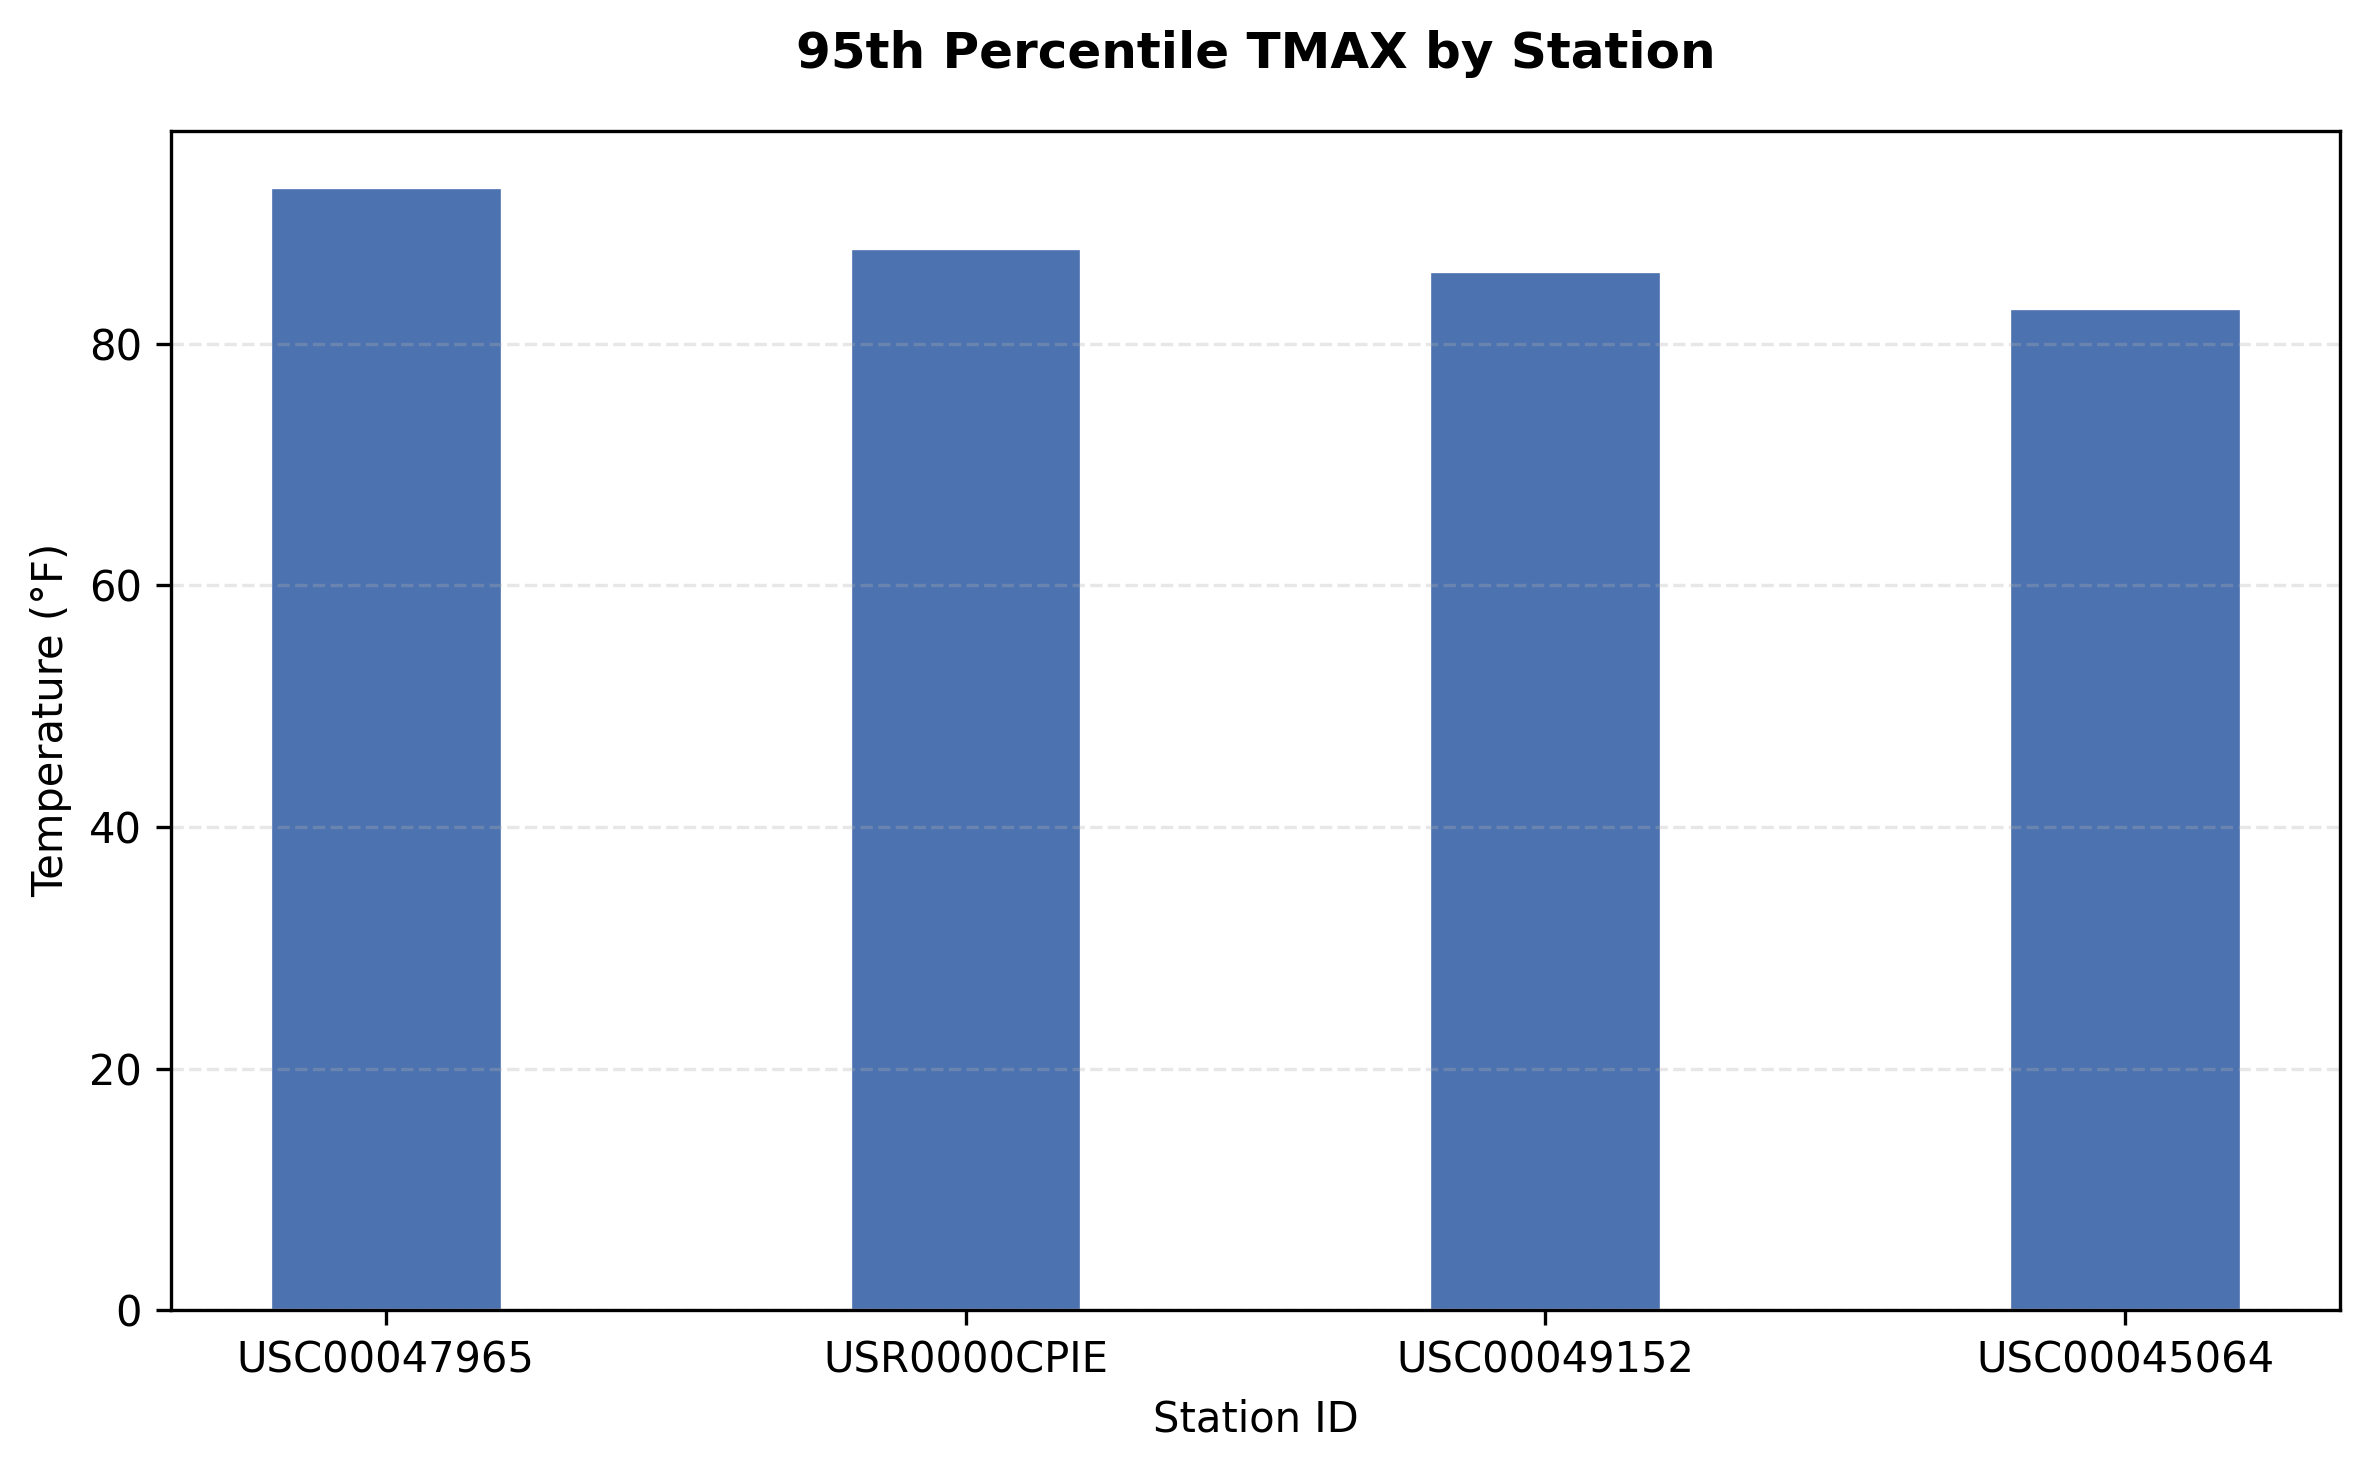

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('clean_daily_temperatures.csv')

# Ensure Fahrenheit column exists
if 'TMAX_F' not in df.columns:
    df['TMAX_F'] = (df['TMAX'] * 9/5) + 32

# Calculate the 95th percentile per station using Fahrenheit and drop any potential NaNs
percentiles = df.groupby('station_id')[['TMAX_F', 'TMIN']].quantile(0.95).reset_index()
percentiles = percentiles.dropna(subset=['TMAX_F'])

# Sort for a clean visual ranking
percentiles = percentiles.sort_values(by='TMAX_F', ascending=False)

# Initialize figure with white background
plt.figure(figsize=(8, 5), dpi=300, facecolor='white')

# Plot as a clean bar chart
plt.bar(
    percentiles['station_id'],
    percentiles['TMAX_F'],
    color='#4c72b0',
    edgecolor='white',
    linewidth=0.8,
    width=0.4
)

# Formatting titles and labels
plt.title('95th Percentile TMAX by Station', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Station ID', fontsize=10)
plt.ylabel('Temperature (°F)', fontsize=10) # Updated label

# Clean grid styling and layout adjustments
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('Figure_95th_Percentile_Bar_F.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

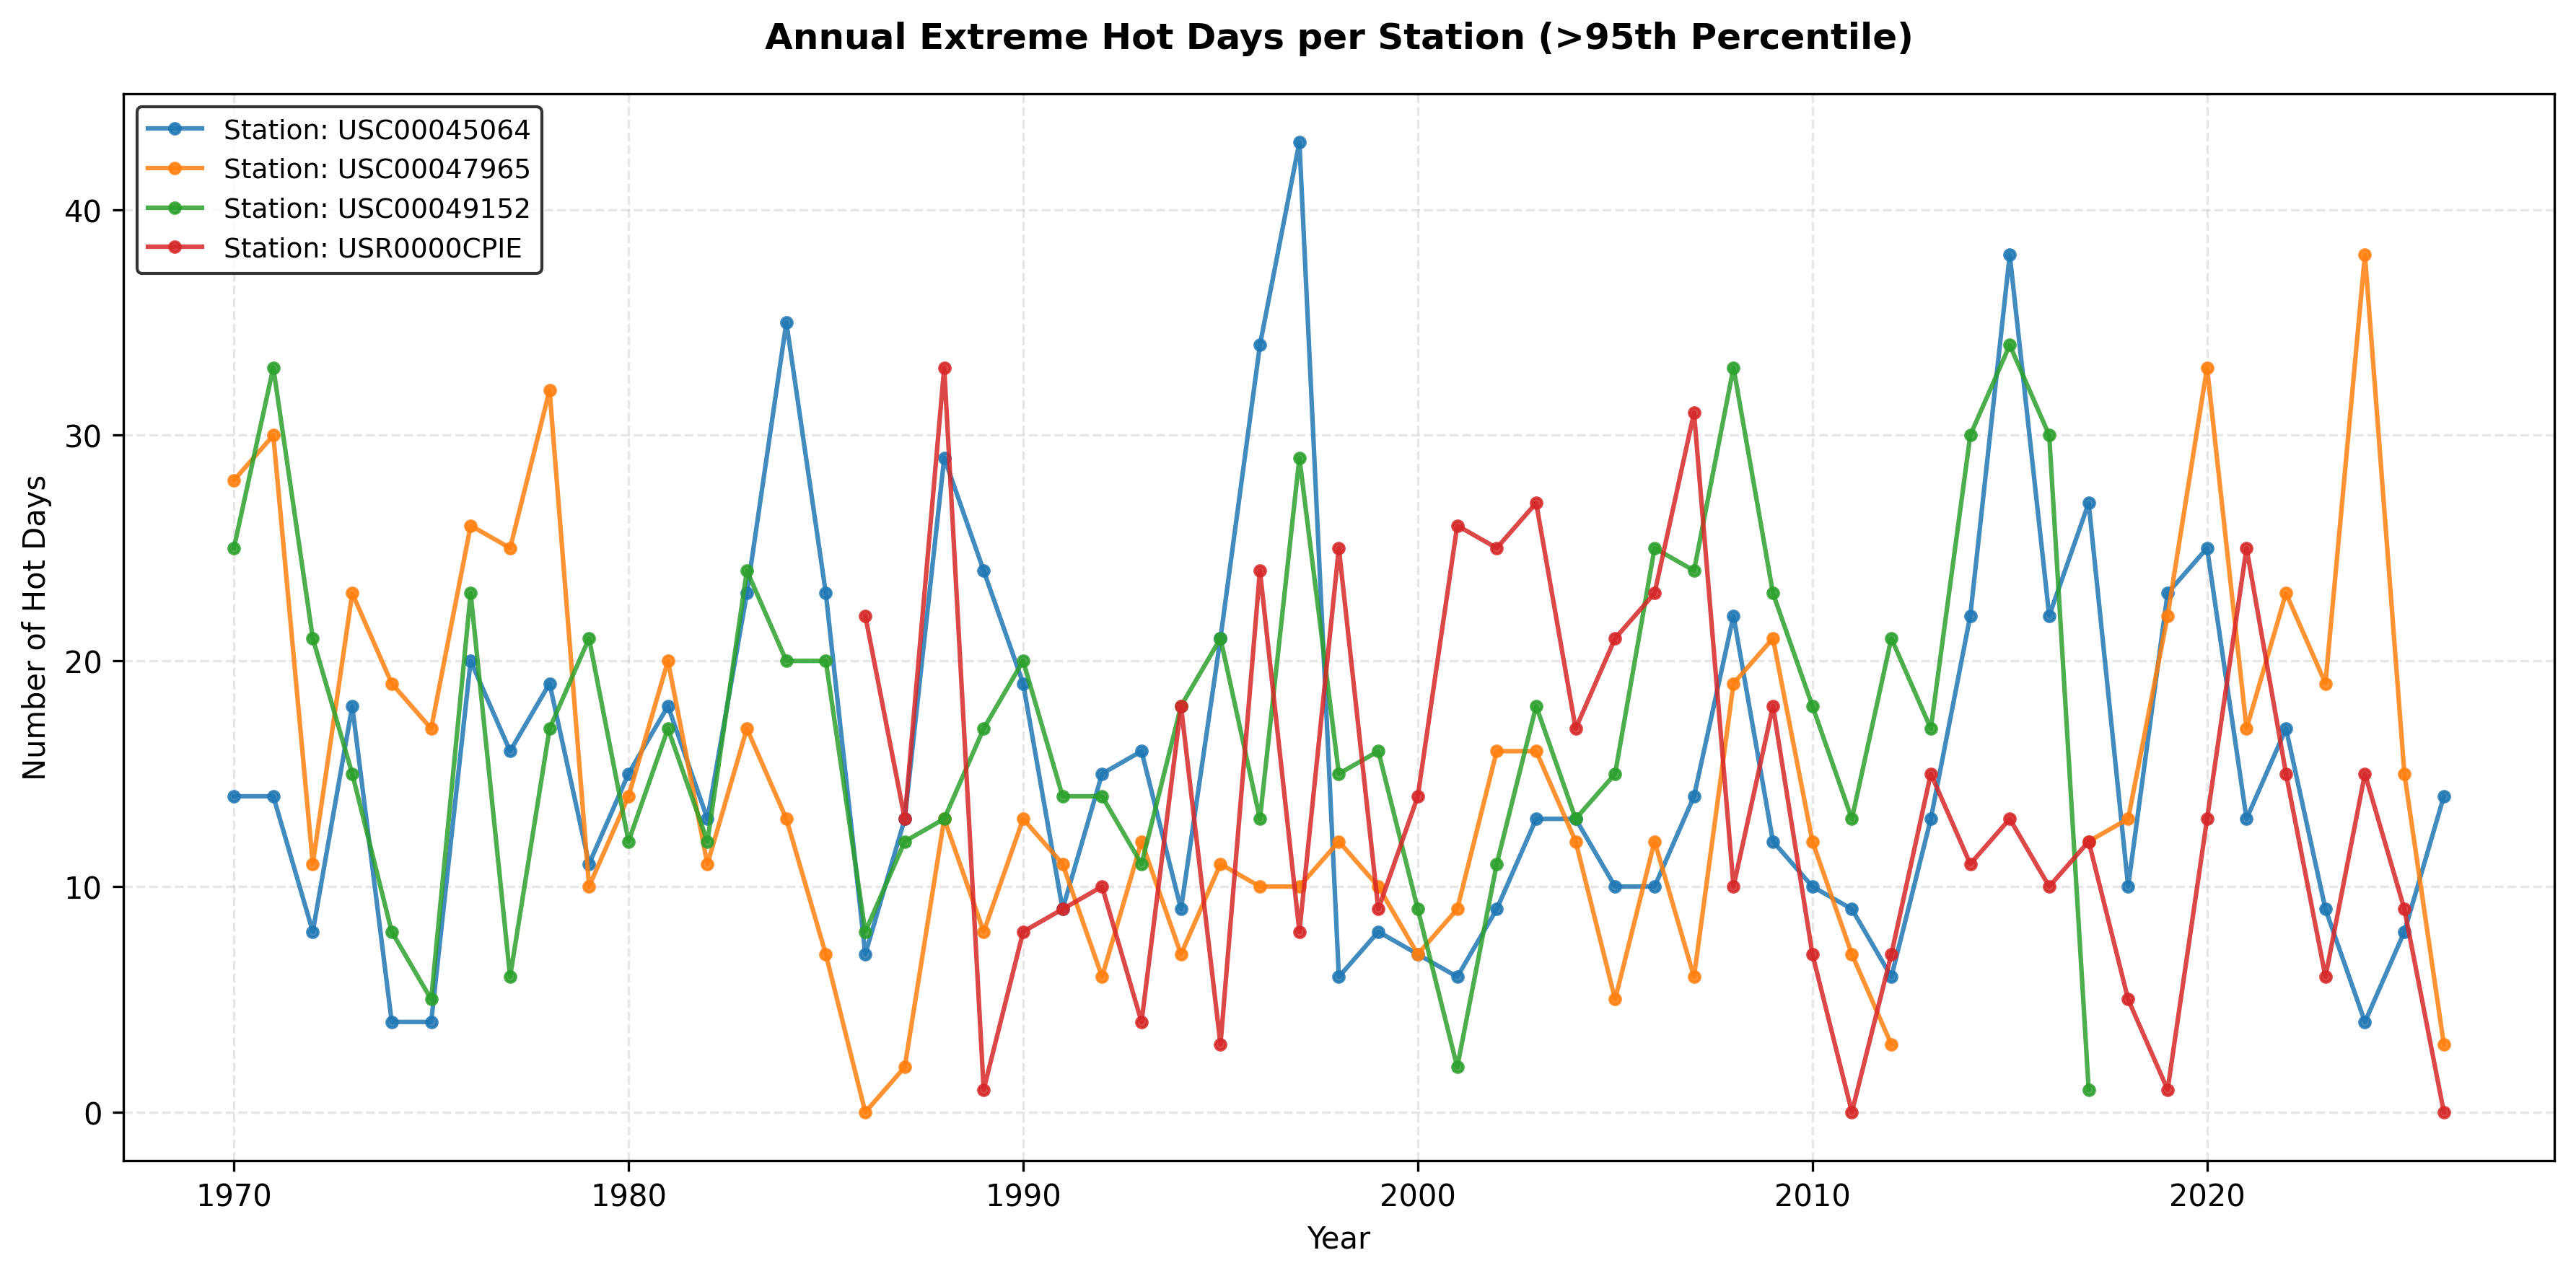

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('clean_daily_temperatures.csv')

# Ensure Fahrenheit column exists
if 'TMAX_F' not in df.columns:
    df['TMAX_F'] = (df['TMAX'] * 9/5) + 32

# Calculate 95th percentile thresholds using Fahrenheit and identify extreme hot days
thresholds_f = df.groupby('station_id')[['TMAX_F', 'TMIN']].quantile(0.95)
df_f = df.merge(thresholds_f, on='station_id', suffixes=('', '_95th'))
df_f['is_hot_day'] = df_f['TMAX_F'] > df_f['TMAX_F_95th']
yearly_extremes_f = df_f.groupby(['year', 'station_id'])[
    'is_hot_day'
].sum()

# Reshape data into a wide format for all available stations
plot_data = yearly_extremes_f.unstack()

# Initialize figure with high print quality resolution (White background)
plt.figure(figsize=(12, 6), dpi=300, facecolor='white')

# Plot each station's hot day trend with refined styling and markers
for col in plot_data.columns:
    plt.plot(
        plot_data.index,
        plot_data[col],
        label=f'Station: {col}',
        linewidth=1.5,
        marker='o',
        markersize=3.5,
        alpha=0.85,
    )

# Formatting titles and labels
plt.title('Annual Extreme Hot Days per Station (>95th Percentile)', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Year', fontsize=10)
plt.ylabel('Number of Hot Days', fontsize=10)

# Clean grid styling and layout adjustments
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, facecolor='white', edgecolor='black', fontsize=9)
plt.tight_layout()

# Save at high print quality
plt.savefig(
    'Figure_Extreme_Hot_Days_F.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()